In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

import sys
import os
import pathlib
import pickle
import itertools

from omegaconf import OmegaConf

In [2]:
run_info_dict = {
    "random": list(),
    "neighbors": list(),
    "pos": list()
}

In [3]:
path = pathlib.Path(r'C:\Users\Vladimir\PycharmProjects\EEGPatternRecognition\dumps\sym_no_reg\random_init')
print(f"{path=}")

weights_seed_ls=np.array([428, 11923, 445, 5794, 14642, 43219, 2267, 11469, 15392, 1108, 665, 1462, 32026, 59966, 377, 269])
adj_seed_ls = np.array([4615, 15306, 15564, 9983])
run_name = "random_init"

for weights_seed, adj_seed in itertools.product(weights_seed_ls, adj_seed_ls):
    with open(path / f"dump_{run_name}_seed_{weights_seed}_adj_{adj_seed}.bin", 'rb') as f:
        run_info = pickle.load(f)
    
    run_info_dict['random'].append(run_info)

path=WindowsPath('C:/Users/Vladimir/PycharmProjects/EEGPatternRecognition/dumps/sym_no_reg/random_init')


In [4]:
path = pathlib.Path(r'C:\Users\Vladimir\PycharmProjects\EEGPatternRecognition\dumps\asym_no_reg\neighbors_init')
print(f"{path=}")

adj_seed_ls=np.array([428, 11923, 445, 5794, 14642, 43219, 2267, 11469, 15392, 1108, 665, 1462, 32026, 59966, 377, 269])
weights_seed_ls=np.array([428, 11923, 445, 5794, 14642, 43219, 2267, 11469, 15392, 1108, 665, 1462, 32026, 59966, 377, 269])
run_name = "neighbors_init"

for adj_seed, weights_seed in zip(adj_seed_ls, weights_seed_ls):
    with open(path / f"dump_{run_name}_seed_{weights_seed}_adj_{adj_seed}.bin", 'rb') as f:
        run_info = pickle.load(f)
    
    run_info_dict['neighbors'].append(run_info)

path=WindowsPath('C:/Users/Vladimir/PycharmProjects/EEGPatternRecognition/dumps/asym_no_reg/neighbors_init')


In [5]:
path = pathlib.Path(r'C:\Users\Vladimir\PycharmProjects\EEGPatternRecognition\dumps\sym_no_reg\pos_init')
print(f"{path=}")

adj_seed_ls=np.array([428, 11923, 445, 5794, 14642, 43219, 2267, 11469, 15392, 1108, 665, 1462, 32026, 59966, 377, 269])
weights_seed_ls=np.array([428, 11923, 445, 5794, 14642, 43219, 2267, 11469, 15392, 1108, 665, 1462, 32026, 59966, 377, 269])
run_name = "pos_init"

for adj_seed, weights_seed in zip(adj_seed_ls, weights_seed_ls):
    with open(path / f"dump_{run_name}_seed_{weights_seed}_adj_{adj_seed}.bin", 'rb') as f:
        run_info = pickle.load(f)
    
    run_info_dict['pos'].append(run_info)

path=WindowsPath('C:/Users/Vladimir/PycharmProjects/EEGPatternRecognition/dumps/sym_no_reg/pos_init')


In [6]:
run_info_dict.keys()

dict_keys(['random', 'neighbors', 'pos'])

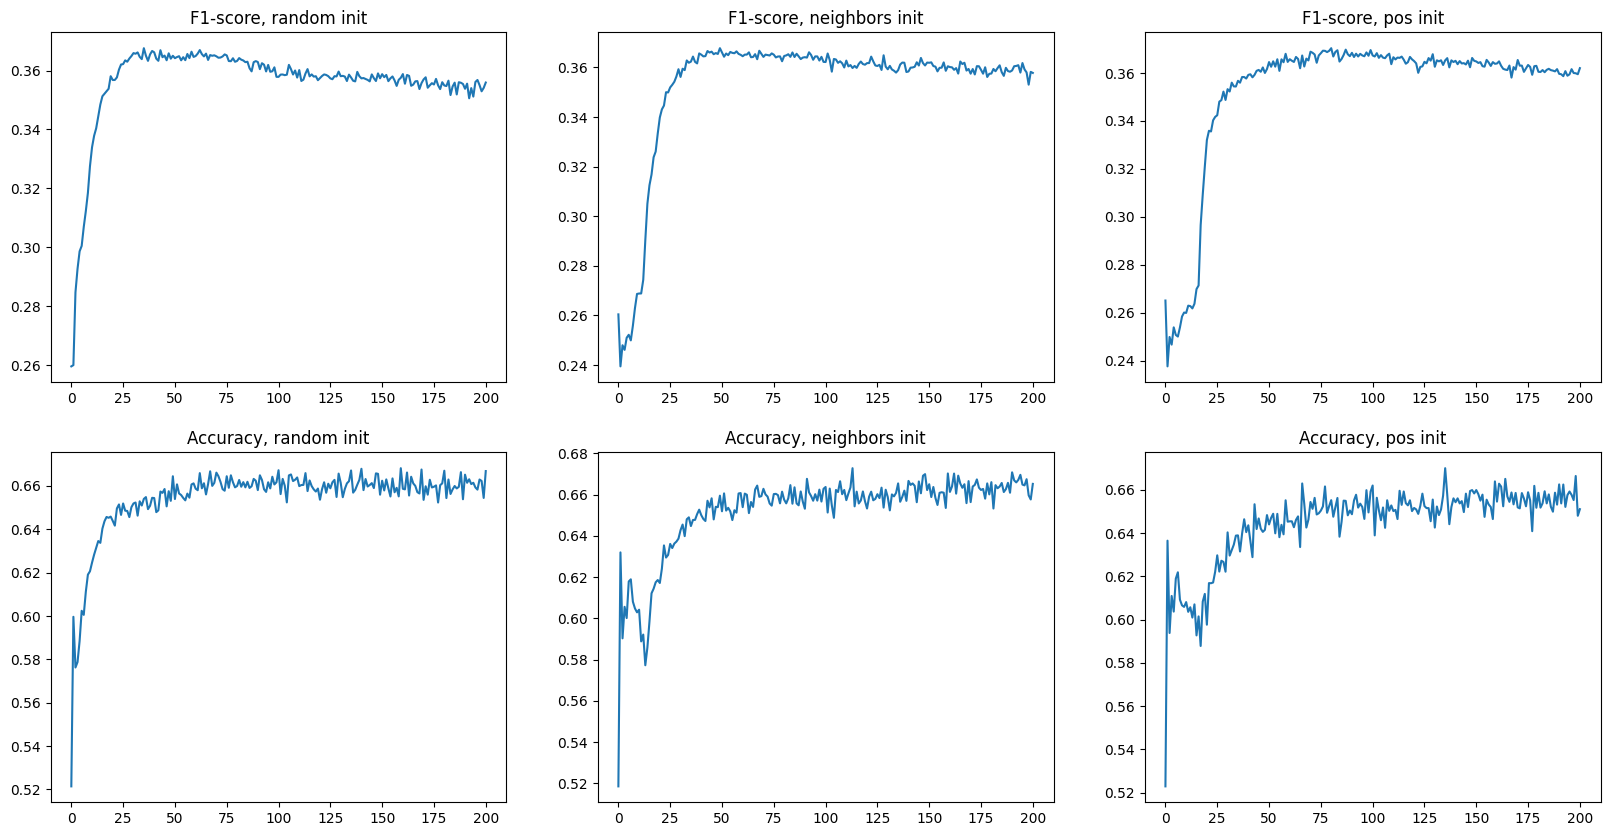

In [7]:
_, ax = plt.subplots(ncols=3, nrows=2, figsize=(20, 10))

for i, run_name in enumerate(run_info_dict.keys()): 
    ax[0, i].plot(run_info_dict[run_name][0]['train_curve']['validation']['f1'])
    ax[1, i].plot(run_info_dict[run_name][0]['train_curve']['validation']['accuracy'])

    ax[0, i].set_title(f'F1-score, {run_name} init')
    ax[1, i].set_title(f'Accuracy, {run_name} init')

In [8]:
f1 = {run_name: list() for run_name in run_info_dict.keys()}
accuracy = {run_name: list() for run_name in run_info_dict.keys()}

for run_name in run_info_dict.keys():
    for run_info in run_info_dict[run_name]:
        f1[run_name].append(run_info['train_curve']['validation']['f1'])
        accuracy[run_name].append(run_info['train_curve']['validation']['accuracy'])

    f1[run_name] = np.vstack(f1[run_name])
    accuracy[run_name] = np.vstack(accuracy[run_name])

    print(f"Run: {run_name}\t{f1[run_name].shape=}\t{accuracy[run_name].shape=}")

Run: random	f1[run_name].shape=(64, 201)	accuracy[run_name].shape=(64, 201)
Run: neighbors	f1[run_name].shape=(16, 201)	accuracy[run_name].shape=(16, 201)
Run: pos	f1[run_name].shape=(16, 201)	accuracy[run_name].shape=(16, 201)


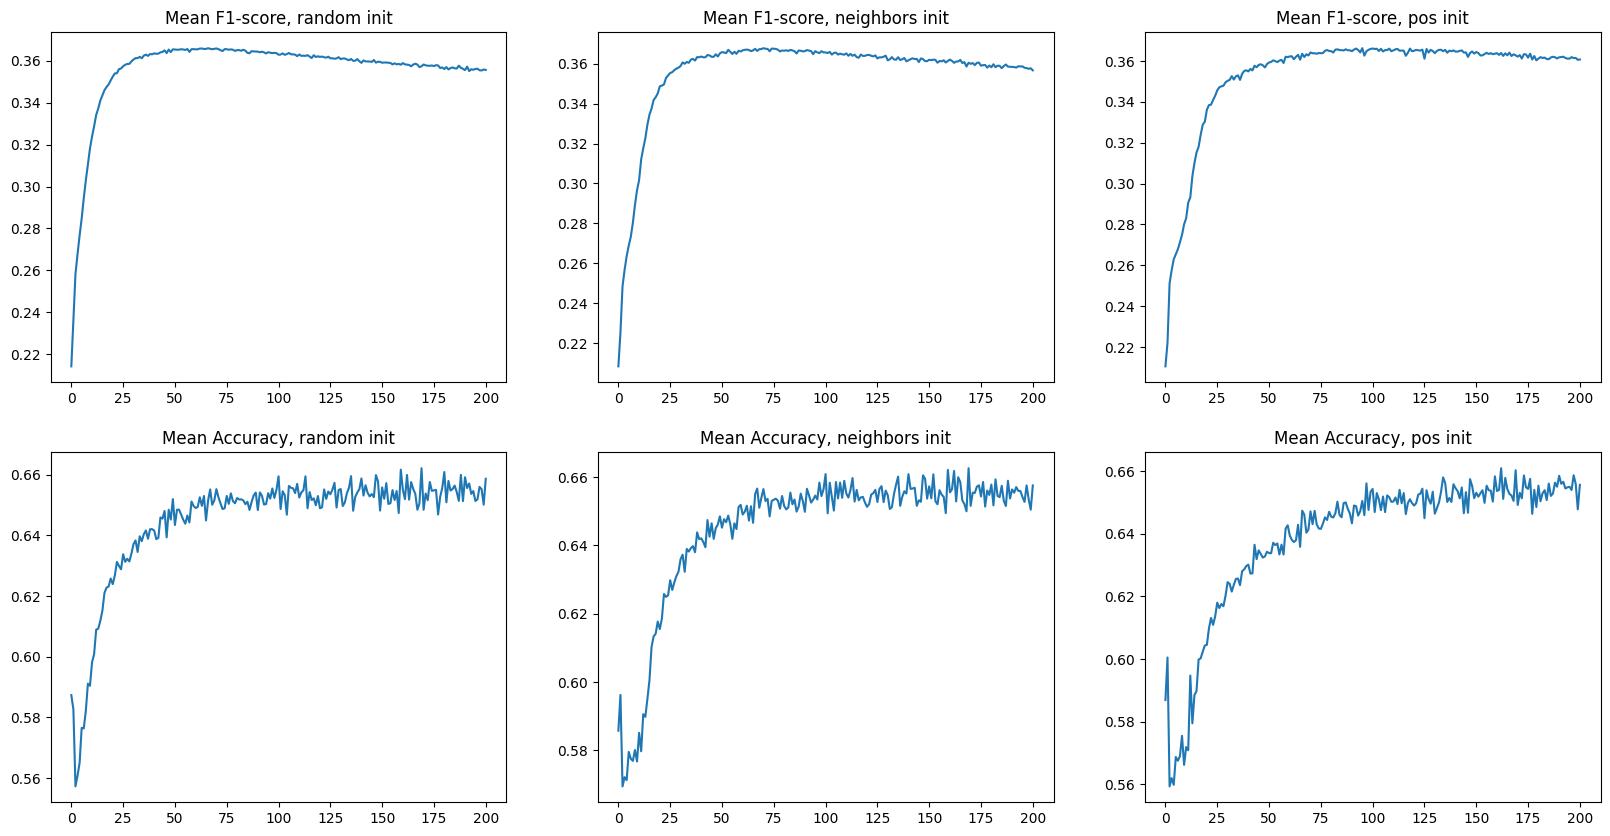

In [9]:
_, ax = plt.subplots(ncols=3, nrows=2, figsize=(20, 10))

for i, run_name in enumerate(run_info_dict.keys()): 
    ax[0, i].plot(np.mean(f1[run_name], axis=0))
    ax[1, i].plot(np.mean(accuracy[run_name], axis=0))

    ax[0, i].set_title(f'Mean F1-score, {run_name} init')
    ax[1, i].set_title(f'Mean Accuracy, {run_name} init')

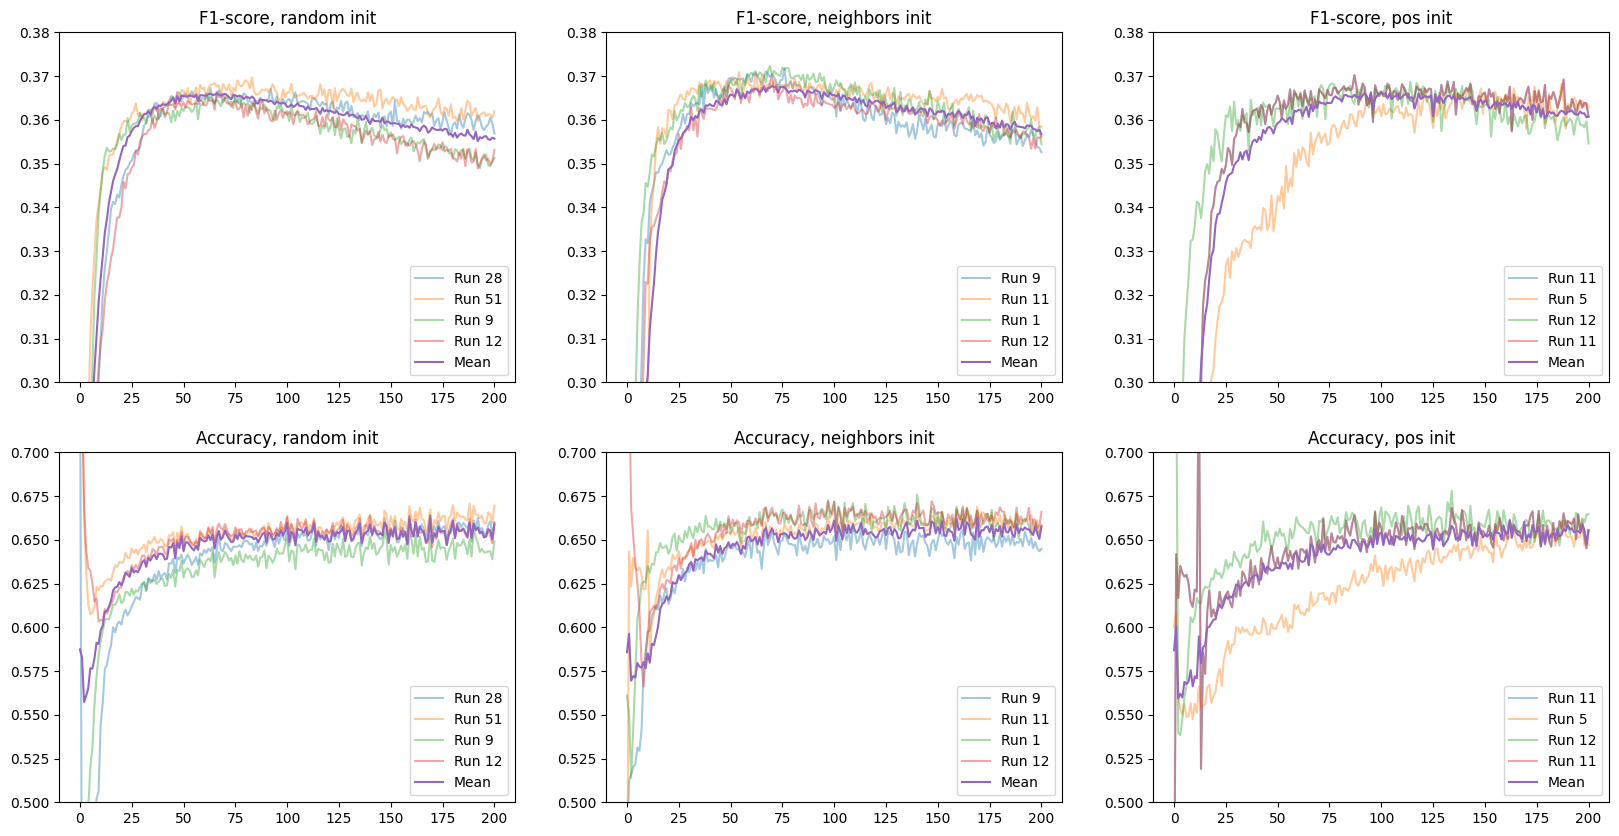

In [10]:
_, ax = plt.subplots(ncols=3, nrows=2, figsize=(20, 10))

for i, run_name in enumerate(run_info_dict.keys()): 
    rand_idxs = np.random.randint(0, f1[run_name].shape[0], size=4)

    for idx in rand_idxs:
        ax[0, i].plot(run_info_dict[run_name][idx]['train_curve']['validation']['f1'], label=f'Run {idx}', alpha=0.4)
        ax[1, i].plot(run_info_dict[run_name][idx]['train_curve']['validation']['accuracy'], label=f'Run {idx}', alpha=0.4)

    ax[0, i].plot(np.mean(f1[run_name], axis=0), label='Mean')
    ax[1, i].plot(np.mean(accuracy[run_name], axis=0), label='Mean')

    ax[0, i].set_title(f'F1-score, {run_name} init')
    ax[1, i].set_title(f'Accuracy, {run_name} init')

    ax[0, i].set_ylim((0.3, 0.38))
    ax[1, i].set_ylim((0.5, 0.7))

    ax[0, i].legend()
    ax[1, i].legend()

In [11]:
best_step_idxs = {}
best_f1 = {}
best_acc = {}

for run_name in run_info_dict.keys():
    best_step_idxs[run_name] = np.argmax(f1[run_name], axis=1)
    best_f1[run_name]  = f1[run_name][np.arange(best_step_idxs[run_name].shape[0]), best_step_idxs[run_name]]
    best_acc[run_name] = accuracy[run_name][np.arange(best_step_idxs[run_name].shape[0]), best_step_idxs[run_name]]

In [12]:
best_f1['random'].shape, best_acc['random'].shape

((64,), (64,))

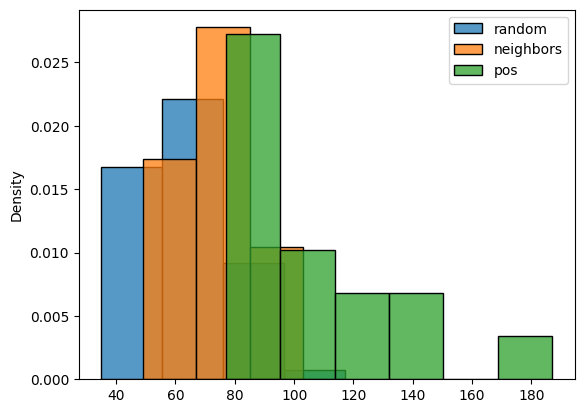

In [13]:
sns.histplot(best_step_idxs['random'], stat='density', binwidth=20, label='random')
sns.histplot(best_step_idxs['neighbors'], stat='density', binwidth=20, label='neighbors')
sns.histplot(best_step_idxs['pos'], stat='density', binwidth=20, label='pos')

plt.legend()

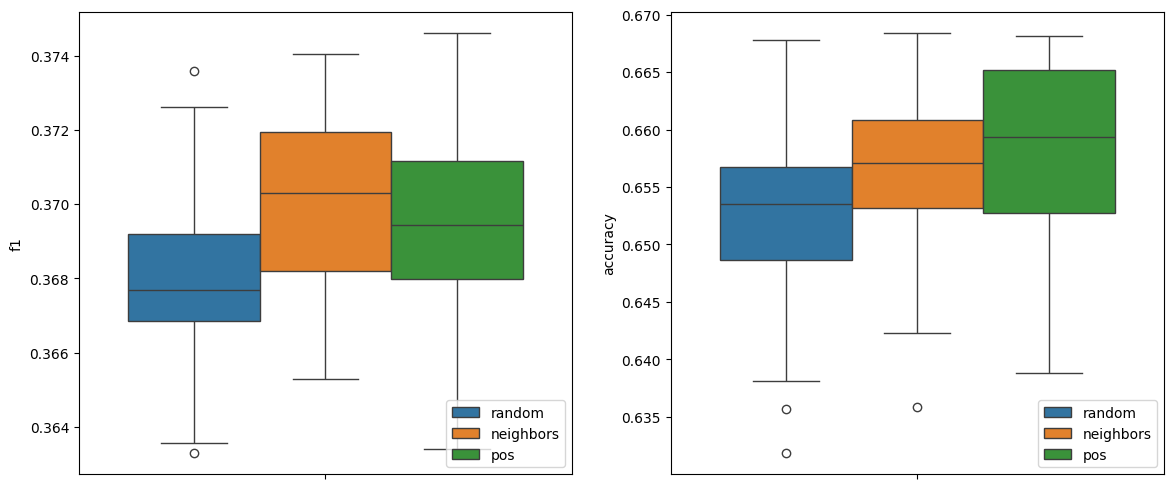

In [14]:
_, ax = plt.subplots(ncols=2, figsize=(14, 6))

score_df = pd.DataFrame(columns=['run_name', 'accuracy', 'f1'])

for run_name in run_info_dict.keys():
    for best_f1_val, best_acc_val in zip(best_f1[run_name], best_acc[run_name]):
        score_df.loc[len(score_df)] = [run_name, best_acc_val, best_f1_val]

sns.boxplot(data=score_df, y='f1', hue='run_name', ax=ax[0])
sns.boxplot(data=score_df, y='accuracy', hue='run_name', ax=ax[1])

ax[0].legend(loc='lower right')
ax[1].legend(loc='lower right')

Random init F1-score:		0.36809	accuracy: 0.65856
Neighbors init F1-score:	0.37229	accuracy: 0.66372
Pos init F1-score:		0.37067	accuracy: 0.66817


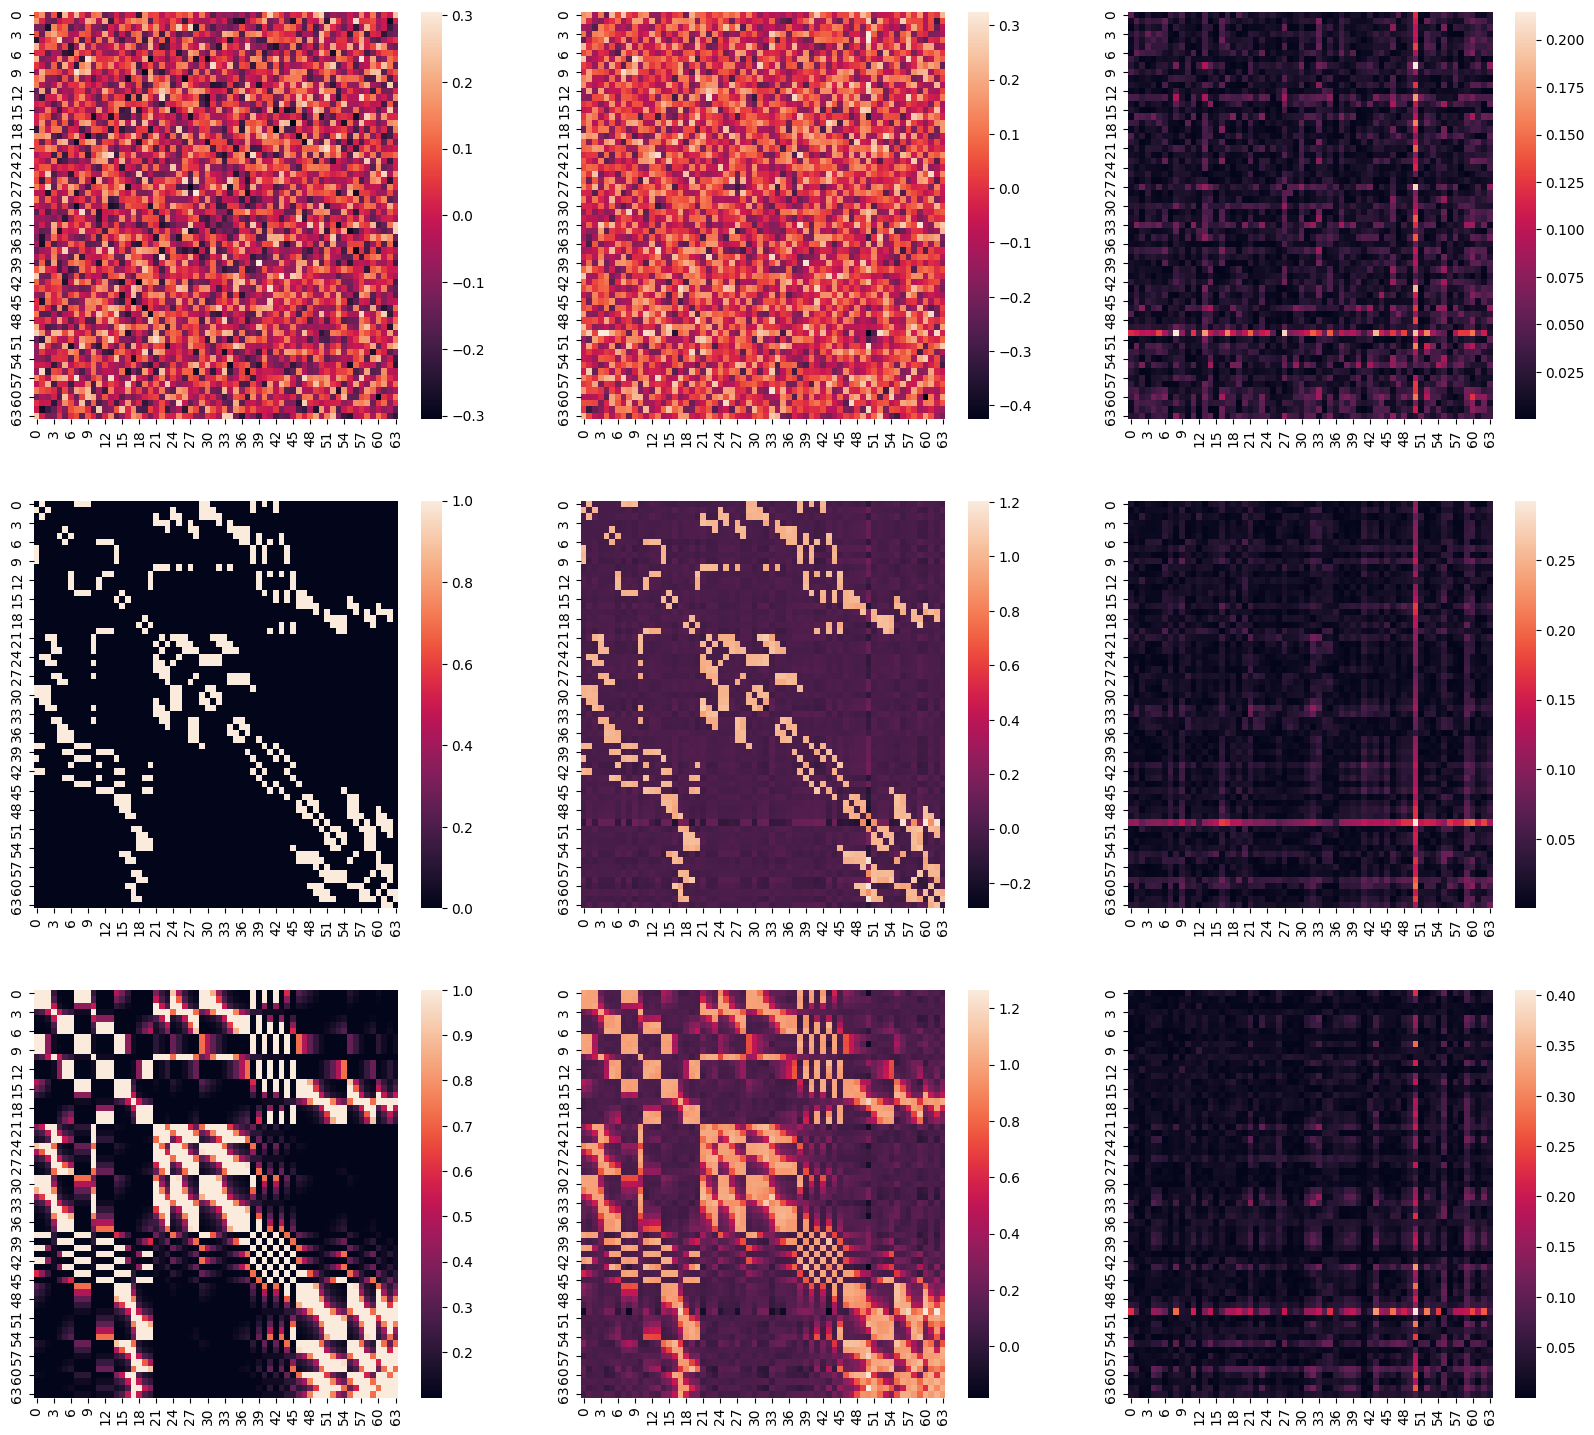

In [15]:
_, ax = plt.subplots(nrows=3, ncols=3, figsize=(20, 18))

adj_idx = 3
weights_idx = 1

idx = weights_idx * 4 + adj_idx
adj_init = run_info_dict['random'][idx]['adj']['init']
adj_final = run_info_dict['random'][idx]['adj']['final']
adj_init = (adj_init + adj_init.T) / 2
adj_final = (adj_final + adj_final.T) / 2
sns.heatmap(adj_init, ax=ax[0, 0])
sns.heatmap(adj_final, ax=ax[0, 1])
sns.heatmap(np.abs(adj_init - adj_final), ax=ax[0, 2])
print(f"Random init F1-score:\t\t{best_f1['random'][idx]:.5f}\taccuracy: {best_acc['random'][idx]:.5f}")


idx = weights_idx
adj_init = run_info_dict['neighbors'][idx]['adj']['init']
adj_final = run_info_dict['neighbors'][idx]['adj']['final']
adj_init = (adj_init + adj_init.T) / 2
adj_final = (adj_final + adj_final.T) / 2
sns.heatmap(adj_init, ax=ax[1, 0])
sns.heatmap(adj_final, ax=ax[1, 1])
sns.heatmap(np.abs(adj_init - adj_final), ax=ax[1, 2])
print(f"Neighbors init F1-score:\t{best_f1['neighbors'][idx]:.5f}\taccuracy: {best_acc['neighbors'][idx]:.5f}")

idx = weights_idx
adj_init = run_info_dict['pos'][idx]['adj']['init']
adj_final = run_info_dict['pos'][idx]['adj']['final']
adj_init = (adj_init + adj_init.T) / 2
adj_final = (adj_final + adj_final.T) / 2
sns.heatmap(adj_init, ax=ax[2, 0])
sns.heatmap(adj_final, ax=ax[2, 1])
sns.heatmap(np.abs(adj_init - adj_final), ax=ax[2, 2])
print(f"Pos init F1-score:\t\t{best_f1['pos'][idx]:.5f}\taccuracy: {best_acc['pos'][idx]:.5f}")